# Quy trình làm sạch dữ liệu sách

Notebook này thay thế luồng tiền xử lý dạng script và trình bày từng bước làm sạch dữ liệu một cách minh bạch, dễ theo dõi để phục vụ trực quan hóa.

## Mục tiêu chính
- Nạp dữ liệu thô từ `data/raw/book_dataset.csv`.
- Làm sạch và chuẩn hóa các cột số, cột văn bản, cột boolean và cột thời gian quan trọng.
- Xử lý các trường đa giá trị (đặc biệt là `authors`) thành dạng dễ phân tích.
- Loại các cột chỉ có một giá trị duy nhất.
- Loại các dòng thiếu dữ liệu ở các cột trọng yếu cho trực quan hóa.
- Xuất dữ liệu đã làm sạch và báo cáo xử lý.

In [7]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root(start: Path) -> Path:
    """Find project root by locating data/raw/book_dataset.csv upward from cwd."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw" / "book_dataset.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/raw/book_dataset.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "book_dataset.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data path: {RAW_PATH}")

Project root: C:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist
Raw data path: C:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist\data\raw\book_dataset.csv


## 1) Nạp dữ liệu thô và kiểm tra nhanh

Bước đầu tiên là đọc file CSV gốc và xem nhanh kích thước, danh sách cột và tình trạng thiếu dữ liệu để hiểu trạng thái ban đầu của dữ liệu trước khi làm sạch.

In [8]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)

print(f"Raw shape: {df_raw.shape}")
print("\nColumns:")
print(df_raw.columns.tolist())

missing_top = df_raw.isna().sum().sort_values(ascending=False).head(15)
print("\nTop missing columns (raw):")
print(missing_top)

df_raw.head(3)

Raw shape: (132955, 26)

Columns:
['id', 'name', 'price', 'list_price', 'discount_rate', 'rating_average', 'review_count', 'all_time_quantity_sold', 'authors', 'publisher_vn', 'manufacturer', 'isbn13', 'book_cover', 'number_of_page', 'publication_date', 'current_seller_name', 'inventory_status', 'stock', 'has_freeship', 'is_authentic', 'has_return_policy', 'cat_level_1', 'cat_level_2', 'cat_level_3', 'cat_level_4', 'cat_level_5']

Top missing columns (raw):
isbn13                    118450
cat_level_5                85931
publication_date           77844
number_of_page             66866
authors                    46694
book_cover                 46084
manufacturer                6372
cat_level_4                 2051
publisher_vn                 659
current_seller_name          376
stock                        376
all_time_quantity_sold         0
discount_rate                  0
rating_average                 0
list_price                     0
dtype: int64


,id,name,price,list_price,discount_rate,rating_average,review_count,all_time_quantity_sold,authors,publisher_vn,manufacturer,isbn13,book_cover,number_of_page,publication_date,current_seller_name,inventory_status,stock,has_freeship,is_authentic,has_return_policy,cat_level_1,cat_level_2,cat_level_3,cat_level_4,cat_level_5
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",83930,109000,23,4.80,7257,75282,Tống Mặc,Skybooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,264.0,2019-01-08,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-ky-nang-song,sach-ky-nang-song,NaN
1,52789367,Sách Nhà Giả Kim (Tái Bản),78000,95000,18,5.00,6076,39825,Paulo Coelho,Nhã Nam,Nhà Xuất Bản Hà Nội,NaN,Bìa mềm,228.0,2020-04-01,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",137830,179000,23,4.80,5492,27187,Cao Minh,Vibooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,424.0,2021-06-01,Tiki Trading,available,"1,000.00",False,True,True,nha-sach-tiki,sach-truyen-tieng-viet,sach-van-hoc,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-nuoc-ngoai


## 2) Khai báo quy tắc làm sạch và hàm hỗ trợ

Phần này định nghĩa:
- Các cột trọng yếu phục vụ trực quan hóa.
- Quy tắc chuyển kiểu dữ liệu.
- Quy tắc chuẩn hóa text và boolean.
- Logic tách nhiều tác giả trong một trường.
- Các hàm tiện ích dùng chung trong toàn bộ pipeline.

In [9]:
# Columns requested for downstream visualizations.
CRITICAL_COLUMNS = [
    "name",
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "review_count",
    "all_time_quantity_sold",
    "authors",
    "current_seller_name",
    "has_freeship",
    "cat_level_2",
    "cat_level_3",
    "number_of_page",
    "publication_year",
]

NUMERIC_COLUMNS = [
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "review_count",
    "all_time_quantity_sold",
    "number_of_page",
]

BOOL_COLUMNS = ["has_freeship", "is_authentic", "has_return_policy"]

# Configurable range filter for page count.
PAGE_RANGE_COLUMN = "number_of_page"
ENABLE_PAGE_RANGE_FILTER = True
PAGE_RANGE_MIN = 1
PAGE_RANGE_MAX = 5000


def normalize_empty_strings(df: pd.DataFrame) -> pd.DataFrame:
    object_cols = df.select_dtypes(include=["object"]).columns.tolist()
    for col in object_cols:
        df[col] = df[col].astype("string").str.strip()
    if object_cols:
        df[object_cols] = df[object_cols].replace(r"^\s*$", pd.NA, regex=True)
    return df


def normalize_boolean(value):
    if pd.isna(value):
        return pd.NA
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        if value == 1:
            return True
        if value == 0:
            return False
    text = str(value).strip().lower()
    if text in {"true", "1", "yes", "y", "t"}:
        return True
    if text in {"false", "0", "no", "n", "f"}:
        return False
    return pd.NA


def split_authors(text: str) -> list[str]:
    """Split author string into multiple authors for long-form analysis."""
    if pd.isna(text):
        return []
    normalized = str(text)
    normalized = re.sub(r"\s+", " ", normalized).strip()
    parts = re.split(r"\s*(?:,|;|/|&|\band\b|\bvà\b)\s*", normalized, flags=re.IGNORECASE)
    parts = [p.strip() for p in parts if p and p.strip()]

    # Remove duplicates while keeping original order.
    seen = set()
    unique_parts = []
    for p in parts:
        key = p.lower()
        if key not in seen:
            seen.add(key)
            unique_parts.append(p)
    return unique_parts


print("Rule setup complete.")
print("Critical columns:", CRITICAL_COLUMNS)
print(
    f"Page-range filter: {ENABLE_PAGE_RANGE_FILTER} | "
    f"{PAGE_RANGE_COLUMN} in [{PAGE_RANGE_MIN}, {PAGE_RANGE_MAX}]"
)

Rule setup complete.
Critical columns: ['name', 'price', 'list_price', 'discount_rate', 'rating_average', 'review_count', 'all_time_quantity_sold', 'authors', 'current_seller_name', 'has_freeship', 'cat_level_2', 'cat_level_3', 'number_of_page', 'publication_year']
Page-range filter: True | number_of_page in [1, 5000]


## 3) Làm sạch và chuẩn hóa dữ liệu

Bước này thực hiện tiền xử lý theo thứ tự rõ ràng:
1. Loại trùng theo sản phẩm.
2. Chuẩn hóa text và boolean.
3. Chuyển kiểu cho cột số/cột ngày.
4. Tạo `publication_year` từ `publication_date`.
5. Áp dụng các ràng buộc logic cơ bản.
6. Điền giá trị thiếu theo chiến lược đã chọn.
7. Lọc dữ liệu theo khoảng `number_of_page` (nếu bật).
8. Loại các cột chỉ có một giá trị (lần 1).
9. Loại dòng thiếu dữ liệu ở các cột trọng yếu.
10. Kiểm tra lại và loại tiếp các cột chỉ có một giá trị sau khi tạo tập dữ liệu mới (lần 2).

In [10]:
df = df_raw.copy()

rows_before = len(df)

# Remove duplicate products by id if available.
if "id" in df.columns:
    df = df.drop_duplicates(subset=["id"], keep="first")
else:
    df = df.drop_duplicates(keep="first")

# Normalize empty strings and trim text columns.
df = normalize_empty_strings(df)

# Convert numeric columns.
for col in NUMERIC_COLUMNS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert booleans.
for col in BOOL_COLUMNS:
    if col in df.columns:
        df[col] = df[col].map(normalize_boolean).astype("boolean")

# Datetime conversion + publication year.
if "publication_date" in df.columns:
    df["publication_date"] = pd.to_datetime(df["publication_date"], errors="coerce")
    df["publication_year"] = df["publication_date"].dt.year.astype("Int64")

# Standardize seller text to reduce duplicates in grouping.
if "current_seller_name" in df.columns:
    df["current_seller_name"] = (
        df["current_seller_name"].astype("string").str.strip().str.lower()
    )

# Standardize category labels.
for cat_col in ["cat_level_1", "cat_level_2", "cat_level_3", "cat_level_4", "cat_level_5"]:
    if cat_col in df.columns:
        df[cat_col] = df[cat_col].astype("string").str.strip().str.lower()

# Parse multi-author field and create helper features.
if "authors" in df.columns:
    df["authors_tokens"] = df["authors"].apply(split_authors)
    df["author_count"] = df["authors_tokens"].apply(len).astype("Int64")
    df["primary_author"] = df["authors_tokens"].apply(lambda x: x[0] if len(x) > 0 else pd.NA)
    df["authors_list"] = df["authors_tokens"].apply(lambda x: " | ".join(x) if len(x) > 0 else pd.NA)

# Basic domain constraints.
for col in ["price", "list_price", "discount_rate", "review_count", "all_time_quantity_sold", "number_of_page"]:
    if col in df.columns:
        df.loc[df[col] < 0, col] = pd.NA

if "rating_average" in df.columns:
    df.loc[(df["rating_average"] < 0) | (df["rating_average"] > 5), "rating_average"] = pd.NA

if "discount_rate" in df.columns:
    df.loc[(df["discount_rate"] < 0) | (df["discount_rate"] > 100), "discount_rate"] = pd.NA

# If list_price is below price, align list_price to price.
if {"price", "list_price"}.issubset(df.columns):
    invalid_price_mask = df["price"].notna() & df["list_price"].notna() & (df["list_price"] < df["price"])
    df.loc[invalid_price_mask, "list_price"] = df.loc[invalid_price_mask, "price"]

# Apply optional page-range filter on page count.
rows_before_page_filter = len(df)
if ENABLE_PAGE_RANGE_FILTER and PAGE_RANGE_COLUMN in df.columns:
    if PAGE_RANGE_MIN > PAGE_RANGE_MAX:
        raise ValueError("PAGE_RANGE_MIN must be less than or equal to PAGE_RANGE_MAX.")
    page_mask = df[PAGE_RANGE_COLUMN].between(PAGE_RANGE_MIN, PAGE_RANGE_MAX, inclusive="both")
    df = df.loc[page_mask].copy()
    page_filter_desc = f"{PAGE_RANGE_COLUMN} in [{PAGE_RANGE_MIN}, {PAGE_RANGE_MAX}]"
else:
    page_filter_desc = "disabled or column missing"
rows_after_page_filter = len(df)

# Requested imputation strategy for rating and review metrics (safe for plotting libs).
for col in ["rating_average", "review_count", "all_time_quantity_sold"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Create aliases asked by the team.
if "rating_average" in df.columns:
    df["rating_rate"] = df["rating_average"]
if "current_seller_name" in df.columns:
    df["current_seller"] = df["current_seller_name"]


def unique_count_safe(series: pd.Series) -> int:
    """Handle unhashable values (like list) when counting unique values."""
    try:
        return int(series.nunique(dropna=False))
    except TypeError:
        normalized = series.apply(lambda x: tuple(x) if isinstance(x, list) else x)
        return int(normalized.nunique(dropna=False))


# Drop columns that contain only one unique value (including NaN as a value).
constant_columns = [
    col for col in df.columns
    if unique_count_safe(df[col]) <= 1
]
df = df.drop(columns=constant_columns)

# Keep only critical columns that still exist after cleaning.
critical_existing = [col for col in CRITICAL_COLUMNS if col in df.columns]

rows_before_critical_drop = len(df)
df_clean = df.dropna(subset=critical_existing).copy()
rows_after_critical_drop = len(df_clean)

# Drop single-value columns again after row-level filtering.
post_clean_constant_columns = [
    col for col in df_clean.columns
    if unique_count_safe(df_clean[col]) <= 1
]
df_clean = df_clean.drop(columns=post_clean_constant_columns)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after page-range filter: {rows_after_page_filter}")
print(f"Dropped rows by page-range filter: {rows_before_page_filter - rows_after_page_filter}")
print(f"Page-range filter config: {page_filter_desc}")
print(f"Rows before critical drop: {rows_before_critical_drop}")
print(f"Rows after critical drop: {rows_after_critical_drop}")
print(f"Dropped rows by critical-null filter: {rows_before_critical_drop - rows_after_critical_drop}")
print(f"Dropped single-value columns (pass 1): {len(constant_columns)}")
print(f"Dropped single-value columns (pass 2): {len(post_clean_constant_columns)}")

{
    "single_value_pass1_sample": constant_columns[:20],
    "single_value_pass2_sample": post_clean_constant_columns[:20],
}

Rows before cleaning: 132955
Rows after page-range filter: 65987
Dropped rows by page-range filter: 66968
Page-range filter config: number_of_page in [1, 5000]
Rows before critical drop: 65987
Rows after critical drop: 36763
Dropped rows by critical-null filter: 29224
Dropped single-value columns (pass 1): 2
Dropped single-value columns (pass 2): 0


{'single_value_pass1_sample': ['stock', 'cat_level_1'],
 'single_value_pass2_sample': []}

## 4) Tạo bảng tác giả dạng long (mở rộng dữ liệu đa giá trị)

Cột `authors` có thể chứa nhiều tác giả trong cùng một dòng. Để trực quan hóa linh hoạt hơn (top tác giả, mức đóng góp theo tác giả...), ta tạo bảng long, trong đó mỗi dòng tương ứng một cặp sách - tác giả.

In [11]:
if "authors_tokens" in df_clean.columns:
    base_cols = [col for col in ["id", "name", "cat_level_2", "cat_level_3", "all_time_quantity_sold"] if col in df_clean.columns]
    authors_long = (
        df_clean[base_cols + ["authors_tokens"]]
        .explode("authors_tokens")
        .rename(columns={"authors_tokens": "author"})
        .dropna(subset=["author"])
    )
    authors_long["author"] = authors_long["author"].astype("string").str.strip()
    authors_long = authors_long[authors_long["author"].ne("")]
else:
    authors_long = pd.DataFrame()

print(f"Author-long rows: {len(authors_long)}")
authors_long.head(5)

Author-long rows: 41766


,id,name,cat_level_2,cat_level_3,all_time_quantity_sold,author
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",sach-truyen-tieng-viet,sach-ky-nang-song,"75,282.00",Tống Mặc
1,52789367,Sách Nhà Giả Kim (Tái Bản),sach-truyen-tieng-viet,sach-van-hoc,"39,825.00",Paulo Coelho
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",sach-truyen-tieng-viet,sach-van-hoc,"27,187.00",Cao Minh
3,278277832,Sách Vui Vẻ Không Quạu Nha - Tản Văn,sach-truyen-tieng-viet,sach-van-hoc,13.00,Ở Đây Zui Nè
4,71345381,Sách Thay Đổi Cuộc Sống Với Nhân Số Học - Lê Đ...,sach-truyen-tieng-viet,sach-ky-nang-song,"31,431.00",David A. Phillips


## 5) Xuất dữ liệu đã làm sạch và báo cáo xử lý

Ta sẽ lưu:
- Bảng dữ liệu chính đã làm sạch để trực quan hóa.
- Bảng tác giả dạng long phục vụ phân tích đa tác giả.
- Báo cáo JSON gồm số dòng, cột bị loại và các chỉ số kiểm tra chất lượng dữ liệu.

In [12]:
main_output_path = OUTPUT_DIR / "book_dataset_clean_notebook.csv"
author_output_path = OUTPUT_DIR / "book_dataset_authors_long_notebook.csv"
report_output_path = OUTPUT_DIR / "book_dataset_clean_notebook_report.json"

# Drop list column before CSV export to keep file format simple.
df_export = df_clean.copy()
if "authors_tokens" in df_export.columns:
    df_export = df_export.drop(columns=["authors_tokens"])

# Prioritize column order for downstream users.
preferred_order = [
    "id",
    "name",
    "authors",
    "authors_list",
    "primary_author",
    "author_count",
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "rating_rate",
    "review_count",
    "all_time_quantity_sold",
    "current_seller_name",
    "current_seller",
    "has_freeship",
    "cat_level_2",
    "cat_level_3",
    "number_of_page",
    "publication_date",
    "publication_year",
]
existing_preferred = [c for c in preferred_order if c in df_export.columns]
remaining_cols = [c for c in df_export.columns if c not in existing_preferred]
df_export = df_export[existing_preferred + remaining_cols]

# Final single-value drop to guarantee exported data has no constant fields.
final_constant_columns = [
    col for col in df_export.columns
    if unique_count_safe(df_export[col]) <= 1
]
if final_constant_columns:
    df_export = df_export.drop(columns=final_constant_columns)

df_export.to_csv(main_output_path, index=False, encoding="utf-8-sig")
authors_long.to_csv(author_output_path, index=False, encoding="utf-8-sig")

missing_after = {col: int(df_export[col].isna().sum()) for col in CRITICAL_COLUMNS if col in df_export.columns}
all_single_value_columns = sorted(
    set(constant_columns)
    | set(post_clean_constant_columns)
    | set(final_constant_columns)
)

report = {
    "input_path": str(RAW_PATH),
    "main_output_path": str(main_output_path),
    "author_output_path": str(author_output_path),
    "raw_rows": int(len(df_raw)),
    "rows_after_cleaning": int(len(df_export)),
    "rows_dropped_by_page_range_filter": int(rows_before_page_filter - rows_after_page_filter),
    "rows_dropped_by_critical_missing": int(rows_before_critical_drop - rows_after_critical_drop),
    "page_range_filter": {
        "enabled": ENABLE_PAGE_RANGE_FILTER,
        "column": PAGE_RANGE_COLUMN,
        "min": PAGE_RANGE_MIN,
        "max": PAGE_RANGE_MAX,
    },
    "dropped_single_value_columns_pass1": constant_columns,
    "dropped_single_value_columns_pass2": post_clean_constant_columns,
    "dropped_single_value_columns_final_export": final_constant_columns,
    "dropped_single_value_columns": all_single_value_columns,
    "critical_columns_used": [col for col in CRITICAL_COLUMNS if col in df_export.columns],
    "critical_missing_after_cleaning": missing_after,
    "output_columns": df_export.columns.tolist(),
}

report_output_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Main dataset saved to: {main_output_path}")
print(f"Author-long dataset saved to: {author_output_path}")
print(f"Report saved to: {report_output_path}")
print(f"Final shape: {df_export.shape}")
print(f"Single-value columns dropped (all passes): {len(all_single_value_columns)}")

Main dataset saved to: C:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist\data\processed\book_dataset_clean_notebook.csv
Author-long dataset saved to: C:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist\data\processed\book_dataset_authors_long_notebook.csv
Report saved to: C:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist\data\processed\book_dataset_clean_notebook_report.json
Final shape: (36763, 30)
Single-value columns dropped (all passes): 2


## 6) Kiểm tra sau làm sạch để sẵn sàng trực quan hóa

Bước kiểm tra cuối cùng đảm bảo các cột bắt buộc còn tồn tại và không còn thiếu dữ liệu sau khi lọc.

In [13]:
missing_summary = (
    df_export[[c for c in CRITICAL_COLUMNS if c in df_export.columns]]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("Critical-column missing values after cleaning:")
print(missing_summary)

print("\nSample rows from cleaned dataset:")
df_export.head(5)

Critical-column missing values after cleaning:
name                      0
price                     0
list_price                0
discount_rate             0
rating_average            0
review_count              0
all_time_quantity_sold    0
authors                   0
current_seller_name       0
has_freeship              0
cat_level_2               0
cat_level_3               0
number_of_page            0
publication_year          0
dtype: int64

Sample rows from cleaned dataset:


,id,name,authors,authors_list,primary_author,author_count,price,list_price,discount_rate,rating_average,rating_rate,review_count,all_time_quantity_sold,current_seller_name,current_seller,has_freeship,cat_level_2,cat_level_3,number_of_page,publication_date,publication_year,publisher_vn,manufacturer,isbn13,book_cover,inventory_status,is_authentic,has_return_policy,cat_level_4,cat_level_5
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",Tống Mặc,Tống Mặc,Tống Mặc,1,"83,930.00","109,000.00",23.00,4.80,4.80,"7,257.00","75,282.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-ky-nang-song,264.00,2019-01-08,2019,Skybooks,Nhà Xuất Bản Thế Giới,<NA>,Bìa mềm,available,True,True,sach-ky-nang-song,<NA>
1,52789367,Sách Nhà Giả Kim (Tái Bản),Paulo Coelho,Paulo Coelho,Paulo Coelho,1,"78,000.00","95,000.00",18.00,5.00,5.00,"6,076.00","39,825.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,228.00,2020-04-01,2020,Nhã Nam,Nhà Xuất Bản Hà Nội,<NA>,Bìa mềm,available,True,True,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",Cao Minh,Cao Minh,Cao Minh,1,"137,830.00","179,000.00",23.00,4.80,4.80,"5,492.00","27,187.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,424.00,2021-06-01,2021,Vibooks,Nhà Xuất Bản Thế Giới,<NA>,Bìa mềm,available,True,True,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-nuoc-ngoai
3,278277832,Sách Vui Vẻ Không Quạu Nha - Tản Văn,Ở Đây Zui Nè,Ở Đây Zui Nè,Ở Đây Zui Nè,1,"60,830.00","79,000.00",23.00,4.70,4.70,"5,338.00",13.00,tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,280.00,2020-03-01,2020,Skybooks,Nhà Xuất Bản Phụ Nữ,<NA>,Bìa mềm,available,True,True,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-viet-nam
4,71345381,Sách Thay Đổi Cuộc Sống Với Nhân Số Học - Lê Đ...,David A. Phillips,David A. Phillips,David A. Phillips,1,"173,462.00","248,000.00",30.00,4.80,4.80,"5,294.00","31,431.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-ky-nang-song,342.00,2020-10-01,2020,First News - Trí Việt,Nhà Xuất Bản Tổng hợp TP.HCM,<NA>,Bìa gập,available,True,True,sach-ky-nang-song,<NA>


## 7) Phân tích khám phá dữ liệu (EDA) trên dữ liệu đã làm sạch

Phần này mở rộng yêu cầu của giảng viên:
- Đánh giá tổng quan dữ liệu: kích thước mẫu, cấu trúc, kiểu dữ liệu.
- Kiểm tra chất lượng dữ liệu: thiếu dữ liệu, trùng lặp, tính nhất quán.
- Phân tích phân bố các biến chính (định lượng và định tính).
- Phân tích quan hệ giữa các biến để hỗ trợ insight cho trực quan hóa.

In [14]:
# Load the cleaned dataset from disk to ensure EDA reproducibility.
EDA_PATH = OUTPUT_DIR / "book_dataset_clean_notebook.csv"
if not EDA_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {EDA_PATH}")

eda_df = pd.read_csv(EDA_PATH, encoding="utf-8-sig", low_memory=False)
if "publication_date" in eda_df.columns:
    eda_df["publication_date"] = pd.to_datetime(eda_df["publication_date"], errors="coerce")

print(f"EDA file: {EDA_PATH}")
print(f"Rows: {len(eda_df):,} | Columns: {eda_df.shape[1]}")
eda_df.head(5)

EDA file: C:\Users\ACER\Desktop\Work\Project\DataVis\Lab\PlotTwist\data\processed\book_dataset_clean_notebook.csv
Rows: 36,763 | Columns: 30


,id,name,authors,authors_list,primary_author,author_count,price,list_price,discount_rate,rating_average,rating_rate,review_count,all_time_quantity_sold,current_seller_name,current_seller,has_freeship,cat_level_2,cat_level_3,number_of_page,publication_date,publication_year,publisher_vn,manufacturer,isbn13,book_cover,inventory_status,is_authentic,has_return_policy,cat_level_4,cat_level_5
0,26114399,"Sách Nóng Giận Là Bản Năng , Tĩnh Lặng Là Bản ...",Tống Mặc,Tống Mặc,Tống Mặc,1,"83,930.00","109,000.00",23.00,4.80,4.80,"7,257.00","75,282.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-ky-nang-song,264.00,2019-01-08,2019,Skybooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,available,True,True,sach-ky-nang-song,NaN
1,52789367,Sách Nhà Giả Kim (Tái Bản),Paulo Coelho,Paulo Coelho,Paulo Coelho,1,"78,000.00","95,000.00",18.00,5.00,5.00,"6,076.00","39,825.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,228.00,2020-04-01,2020,Nhã Nam,Nhà Xuất Bản Hà Nội,NaN,Bìa mềm,available,True,True,tac-pham-kinh-dien,tac-pham-kinh-dien-nuoc-ngoai
2,109017985,"Sách Thiên Tài Bên Trái, Kẻ Điên Bên Phải (Tái...",Cao Minh,Cao Minh,Cao Minh,1,"137,830.00","179,000.00",23.00,4.80,4.80,"5,492.00","27,187.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,424.00,2021-06-01,2021,Vibooks,Nhà Xuất Bản Thế Giới,NaN,Bìa mềm,available,True,True,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-nuoc-ngoai
3,278277832,Sách Vui Vẻ Không Quạu Nha - Tản Văn,Ở Đây Zui Nè,Ở Đây Zui Nè,Ở Đây Zui Nè,1,"60,830.00","79,000.00",23.00,4.70,4.70,"5,338.00",13.00,tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-van-hoc,280.00,2020-03-01,2020,Skybooks,Nhà Xuất Bản Phụ Nữ,NaN,Bìa mềm,available,True,True,truyen-ngan-tan-van-tap-van,truyen-ngan-tan-van-tap-van-viet-nam
4,71345381,Sách Thay Đổi Cuộc Sống Với Nhân Số Học - Lê Đ...,David A. Phillips,David A. Phillips,David A. Phillips,1,"173,462.00","248,000.00",30.00,4.80,4.80,"5,294.00","31,431.00",tiki trading,tiki trading,False,sach-truyen-tieng-viet,sach-ky-nang-song,342.00,2020-10-01,2020,First News - Trí Việt,Nhà Xuất Bản Tổng hợp TP.HCM,NaN,Bìa gập,available,True,True,sach-ky-nang-song,NaN


## 8) Tổng quan dữ liệu: kích thước mẫu, cấu trúc, kiểu dữ liệu

Phần này trả lời trực tiếp yêu cầu bắt buộc:
- Kích thước mẫu.
- Cấu trúc dữ liệu.
- Kiểu dữ liệu của từng cột.

Đồng thời bổ sung memory usage và tỷ lệ missing theo cột để đánh giá mức độ sẵn sàng cho phân tích.

In [15]:
# High-level dataset overview.
overview_df = pd.DataFrame(
    {
        "metric": ["rows", "columns", "memory_mb"],
        "value": [
            len(eda_df),
            eda_df.shape[1],
            round(eda_df.memory_usage(deep=True).sum() / 1024**2, 3),
        ],
    }
)

display(overview_df)

# Column-level schema profiling.
schema_df = pd.DataFrame(
    {
        "column": eda_df.columns,
        "dtype": eda_df.dtypes.astype(str).values,
        "non_null_count": eda_df.notna().sum().values,
        "missing_count": eda_df.isna().sum().values,
        "unique_count": [eda_df[c].nunique(dropna=True) for c in eda_df.columns],
    }
)
schema_df["missing_rate_%"] = (schema_df["missing_count"] / len(eda_df) * 100).round(3)

display(schema_df.sort_values(["missing_count", "column"], ascending=[False, True]))

dtype_summary = (
    schema_df.groupby("dtype", as_index=False)
    .agg(column_count=("column", "count"), total_missing=("missing_count", "sum"))
    .sort_values("column_count", ascending=False)
)
display(dtype_summary)

,metric,value
0,rows,"36,763.00"
1,columns,30.00
2,memory_mb,49.01


,column,dtype,non_null_count,missing_count,unique_count,missing_rate_%
23,isbn13,object,2011,34752,1902,94.53
29,cat_level_5,object,12716,24047,175,65.41
22,manufacturer,object,33834,2929,400,7.97
24,book_cover,object,36026,737,33,2.00
28,cat_level_4,object,36138,625,186,1.70
21,publisher_vn,object,36756,7,844,0.02
12,all_time_quantity_sold,float64,36763,0,1653,0.00
5,author_count,int64,36763,0,10,0.00
2,authors,object,36763,0,13747,0.00
3,authors_list,object,36763,0,13647,0.00


,dtype,column_count,total_missing
4,object,15,63097
2,float64,8,0
0,bool,3,0
3,int64,3,0
1,datetime64[ns],1,0


## 9) Kiểm tra chất lượng dữ liệu

Phần này tập trung vào:
- Trùng lặp theo `id` và trùng lặp toàn bộ dòng.
- Tỷ lệ missing trên toàn bảng dữ liệu.
- Các cột có cardinality rất thấp hoặc chỉ một giá trị.
- Phát hiện sơ bộ các bất thường logic ở biến chính.

In [16]:
# Duplicate and missing-data audit.
duplicate_id = int(eda_df.duplicated(subset=["id"]).sum()) if "id" in eda_df.columns else np.nan
duplicate_full = int(eda_df.duplicated().sum())
missing_cells = int(eda_df.isna().sum().sum())
total_cells = int(eda_df.shape[0] * eda_df.shape[1])
missing_ratio = (missing_cells / total_cells * 100) if total_cells else np.nan

quality_summary = pd.DataFrame(
    {
        "metric": [
            "duplicate_id_rows",
            "duplicate_full_rows",
            "missing_cells_total",
            "missing_ratio_total_%",
        ],
        "value": [duplicate_id, duplicate_full, missing_cells, round(missing_ratio, 4)],
    }
)
display(quality_summary)

# Columns with extremely low cardinality can reduce analytical value.
low_cardinality = schema_df[schema_df["unique_count"] <= 3].sort_values("unique_count")
display(low_cardinality[["column", "dtype", "unique_count", "missing_rate_%"]])

# Business-rule checks for core numeric fields.
logic_checks = {}
if "price" in eda_df.columns:
    logic_checks["negative_price_count"] = int((eda_df["price"] < 0).sum())
if "list_price" in eda_df.columns:
    logic_checks["negative_list_price_count"] = int((eda_df["list_price"] < 0).sum())
if {"price", "list_price"}.issubset(eda_df.columns):
    logic_checks["list_price_lower_than_price_count"] = int((eda_df["list_price"] < eda_df["price"]).sum())
if "rating_average" in eda_df.columns:
    logic_checks["rating_out_of_0_5_count"] = int(((eda_df["rating_average"] < 0) | (eda_df["rating_average"] > 5)).sum())
if "discount_rate" in eda_df.columns:
    logic_checks["discount_out_of_0_100_count"] = int(((eda_df["discount_rate"] < 0) | (eda_df["discount_rate"] > 100)).sum())

logic_checks_df = pd.DataFrame({"check": list(logic_checks.keys()), "count": list(logic_checks.values())})
display(logic_checks_df)

,metric,value
0,duplicate_id_rows,0.00
1,duplicate_full_rows,0.00
2,missing_cells_total,"63,097.00"
3,missing_ratio_total_%,5.72


,column,dtype,unique_count,missing_rate_%
15,has_freeship,bool,2,0.00
16,cat_level_2,object,2,0.00
25,inventory_status,object,2,0.00
26,is_authentic,bool,2,0.00
27,has_return_policy,bool,2,0.00


,check,count
0,negative_price_count,0
1,negative_list_price_count,0
2,list_price_lower_than_price_count,0
3,rating_out_of_0_5_count,0
4,discount_out_of_0_100_count,0


## 10) Phân bố các biến chính (định lượng)

Phần này phân tích phân bố và độ lệch của các biến định lượng quan trọng:
- `price`, `list_price`, `discount_rate`.
- `rating_average`, `review_count`, `all_time_quantity_sold`.
- `number_of_page`.

Có thêm thống kê outlier theo IQR để chuẩn bị cho trực quan hóa và mô hình hóa.

Numeric focus columns (7): ['price', 'list_price', 'discount_rate', 'rating_average', 'review_count', 'all_time_quantity_sold', 'number_of_page']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
list_price,"36,763.00","175,804.93","166,771.40","5,460.00","20,000.00","38,000.00","88,000.00","139,000.00","207,500.00","435,000.00","803,760.00","5,200,000.00",6.00,82.08
price,"36,763.00","158,214.00","158,527.08",0.00,"18,000.00","32,800.00","75,900.00","120,000.00","189,000.00","390,000.00","768,364.80","5,200,000.00",6.54,98.00
all_time_quantity_sold,"36,763.00",152.29,"1,236.72",0.00,0.00,0.00,0.00,4.00,40.00,445.00,"2,630.80","75,282.00",27.24,"1,045.77"
number_of_page,"36,763.00",311.99,258.73,1.00,16.00,32.00,172.00,272.00,392.00,687.00,"1,300.00","5,000.00",4.29,38.88
review_count,"36,763.00",17.91,146.73,0.00,0.00,0.00,0.00,0.00,3.00,51.00,323.38,"7,257.00",23.05,706.44
discount_rate,"36,763.00",10.56,12.66,0.00,0.00,0.00,0.00,5.00,20.00,34.00,43.00,100.00,0.91,-0.19
rating_average,"36,763.00",2.04,2.39,0.00,0.00,0.00,0.00,0.00,5.00,5.00,5.00,5.00,0.34,-1.86


,column,outlier_count,outlier_rate_%
4,review_count,6255,17.01
5,all_time_quantity_sold,5602,15.24
0,price,2322,6.32
1,list_price,2318,6.30
6,number_of_page,1572,4.28
2,discount_rate,56,0.15
3,rating_average,0,0.00


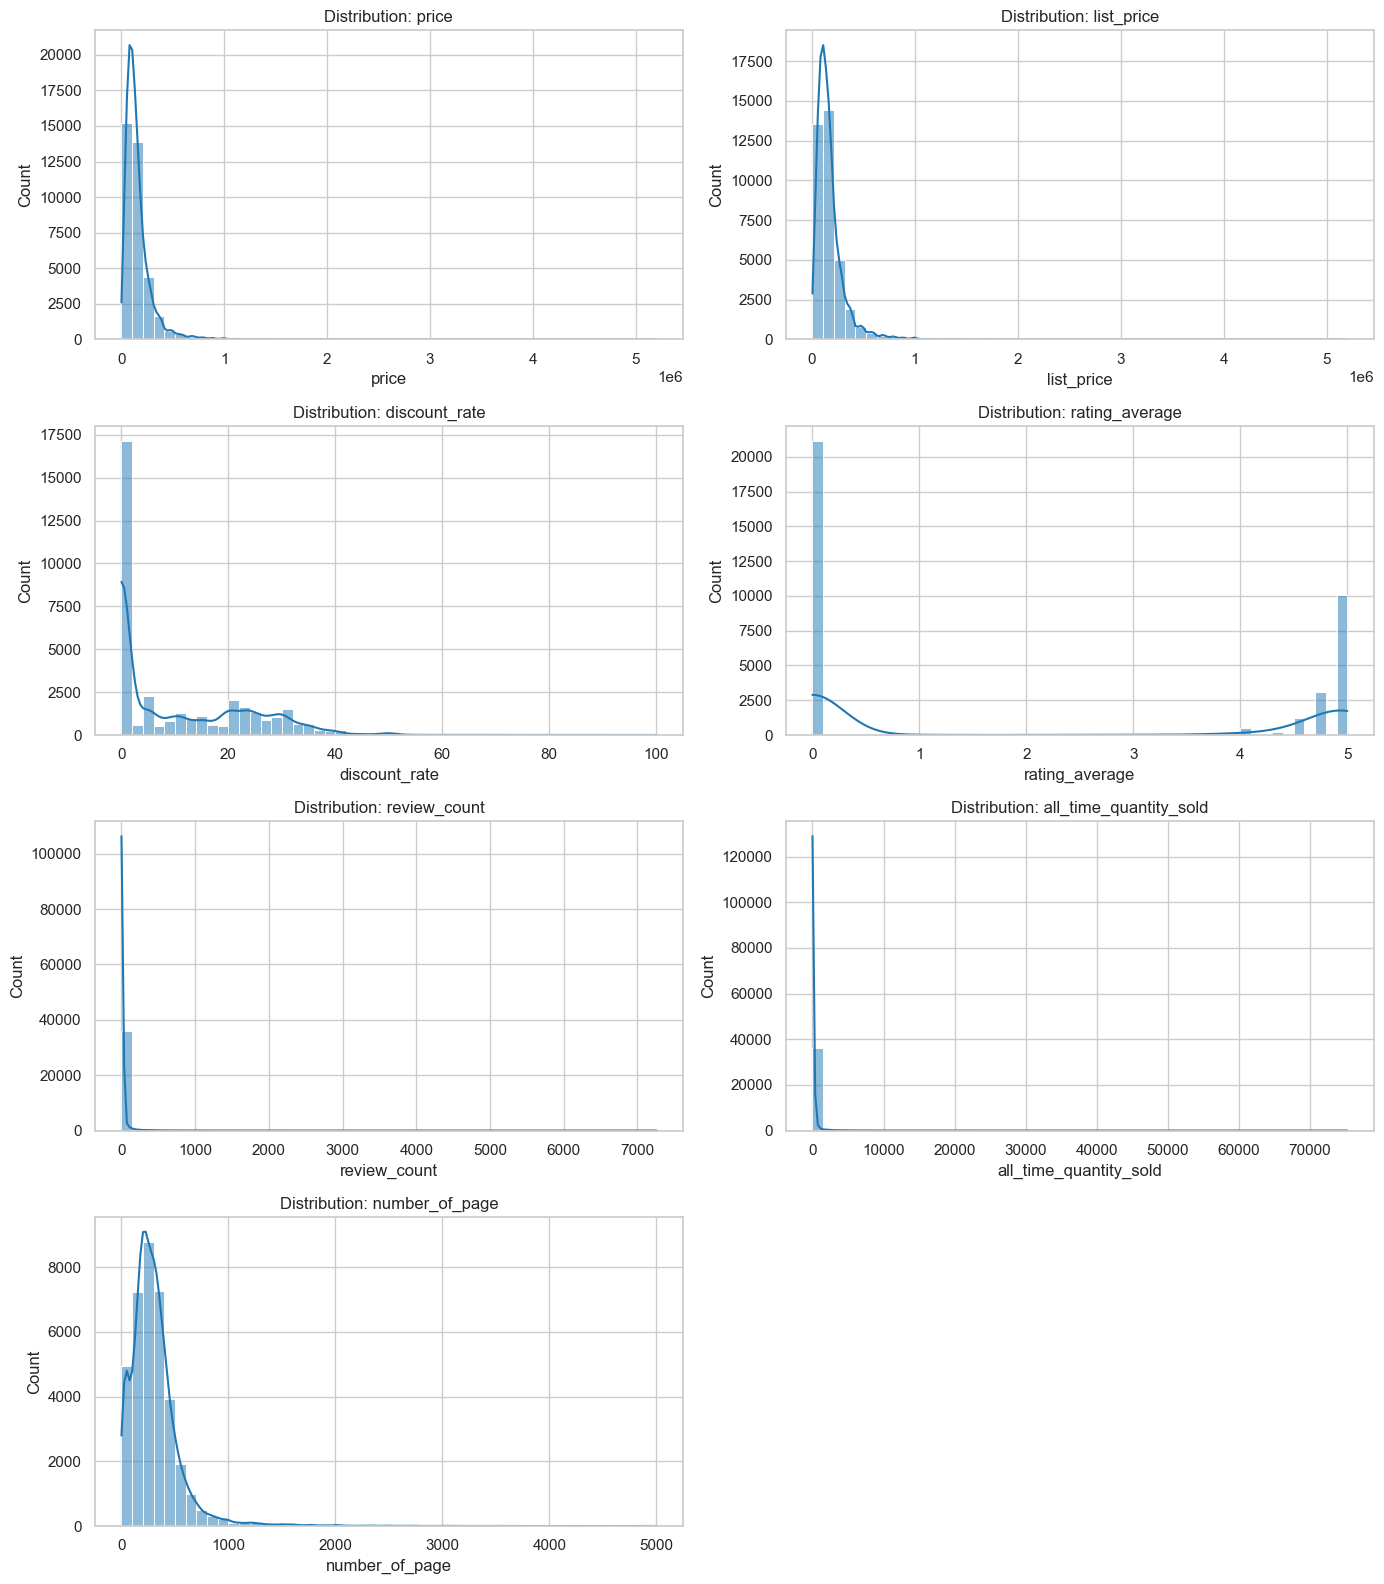

In [17]:
numeric_focus = [
    c for c in [
        "price",
        "list_price",
        "discount_rate",
        "rating_average",
        "review_count",
        "all_time_quantity_sold",
        "number_of_page",
    ]
    if c in eda_df.columns
]

print(f"Numeric focus columns ({len(numeric_focus)}): {numeric_focus}")

if numeric_focus:
    desc = eda_df[numeric_focus].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    desc["skew"] = eda_df[numeric_focus].skew(numeric_only=True)
    desc["kurtosis"] = eda_df[numeric_focus].kurtosis(numeric_only=True)
    display(desc.sort_values("std", ascending=False))

    # IQR-based outlier profile.
    outlier_rows = []
    for col in numeric_focus:
        s = eda_df[col].dropna()
        if s.empty:
            outlier_rows.append({"column": col, "outlier_count": 0, "outlier_rate_%": 0.0})
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:
            outlier_rows.append({"column": col, "outlier_count": 0, "outlier_rate_%": 0.0})
            continue
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = int(((s < lower) | (s > upper)).sum())
        outlier_rows.append(
            {
                "column": col,
                "outlier_count": outlier_count,
                "outlier_rate_%": round(outlier_count / len(s) * 100, 3),
            }
        )
    outlier_df = pd.DataFrame(outlier_rows).sort_values("outlier_rate_%", ascending=False)
    display(outlier_df)

    # Distribution charts.
    n_cols = 2
    n_rows = int(np.ceil(len(numeric_focus) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_focus):
        ax = axes[i]
        series = eda_df[col].dropna()
        if series.empty:
            ax.set_title(f"{col}: no data")
            ax.axis("off")
            continue
        sns.histplot(series, bins=50, kde=True, ax=ax, color="#1f77b4")
        ax.set_title(f"Distribution: {col}")

    for j in range(len(numeric_focus), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

## 11) Phân tích biến định tính (Categorical)

Mục tiêu:
- Đo độ đa dạng của các biến định tính.
- Xác định các nhóm nổi bật theo tần suất.
- Quan sát long-tail để quyết định chiến lược gom nhóm khi trực quan hóa.

,column,unique_values,missing_rate_%
0,name,35776,0.00
1,authors,13747,0.00
2,authors_list,13647,0.00
3,primary_author,12479,0.00
11,isbn13,1902,94.53
9,publisher_vn,844,0.02
10,manufacturer,400,7.97
4,current_seller_name,326,0.00
5,current_seller,326,0.00
16,cat_level_4,186,1.70


Top values for: cat_level_2


,cat_level_2,count,share_%
0,sach-truyen-tieng-viet,34731,94.47
1,sach-tieng-anh,2032,5.53


Top values for: cat_level_3


,cat_level_3,count,share_%
0,sach-van-hoc,8808,23.96
1,sach-truyen-thieu-nhi,4719,12.84
2,sach-kinh-te,4361,11.86
3,sach-kien-thuc-tong-hop,3077,8.37
4,sach-ky-nang-song,2711,7.37
5,ngoai-ngu-tu-dien,2638,7.18
6,sach-tham-khao,1479,4.02
7,nuoi-day-con,1338,3.64
8,ton-giao-tam-linh,1279,3.48
9,lich-su-dia-ly,1264,3.44


...

,current_seller_name,count,share_%
0,tiki trading,9886,26.89
1,nhà sách fahasa,3428,9.32
2,bamboo books,2385,6.49
3,nhà sách netabooks,1679,4.57
4,nhà sách vĩnh thụy,1665,4.53
5,bookworm hà nội,1131,3.08
6,hệ thống nhà sách abc,989,2.69
7,bảo châu books,963,2.62
8,info book,931,2.53
9,alpha books official,892,2.43


Top values for: publisher_vn


,publisher_vn,count,share_%
0,Nhã Nam,2932,7.97
1,NXB Trẻ,2808,7.64
2,Alphabooks,2060,5.60
3,Thái Hà,1480,4.03
4,1980 Books,990,2.69
5,NXB Kim Đồng,931,2.53
6,First News - Trí Việt,883,2.40
7,Nhà Xuất Bản Kim Đồng,825,2.24
8,Nhân Trí Việt,732,1.99
9,Alpha Books,723,1.97


Top values for: primary_author


,primary_author,count,share_%
0,nhieu tac gia,1572,4.28
1,Nhiều tác giả,980,2.67
2,.,589,1.60
3,Many Authors,306,0.83
4,Nguyễn Nhật Ánh,288,0.78
5,Thích Nhất Hạnh,130,0.35
6,Agatha Christie,129,0.35
7,Osho,119,0.32
8,DK,114,0.31
9,Mai Lan Hương,113,0.31


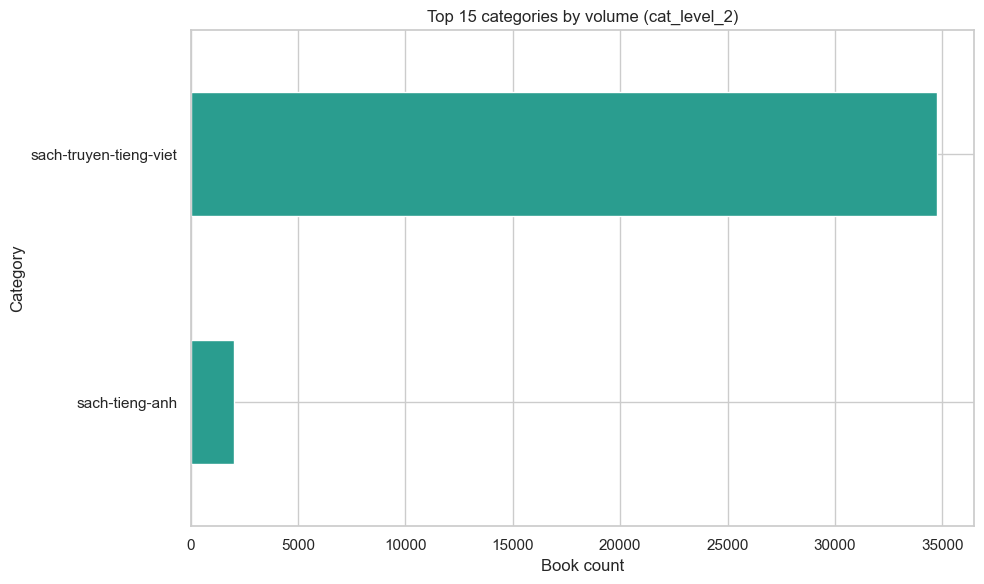

In [18]:
categorical_cols = eda_df.select_dtypes(include=["object", "string", "category", "boolean"]).columns.tolist()
cat_profile = pd.DataFrame(
    {
        "column": categorical_cols,
        "unique_values": [eda_df[c].nunique(dropna=True) for c in categorical_cols],
        "missing_rate_%": [round(eda_df[c].isna().mean() * 100, 3) for c in categorical_cols],
    }
).sort_values(["unique_values", "missing_rate_%"], ascending=[False, False])

display(cat_profile)


def top_counts(dataframe: pd.DataFrame, col: str, top_n: int = 15) -> pd.DataFrame:
    vc = dataframe[col].fillna("<NA>").astype("string").value_counts().head(top_n)
    out = vc.rename_axis(col).reset_index(name="count")
    out["share_%"] = (out["count"] / len(dataframe) * 100).round(3)
    return out


for col in ["cat_level_2", "cat_level_3", "current_seller_name", "publisher_vn", "primary_author"]:
    if col in eda_df.columns:
        print(f"Top values for: {col}")
        display(top_counts(eda_df, col, top_n=15))

if "cat_level_2" in eda_df.columns:
    top_cat2 = eda_df["cat_level_2"].fillna("<NA>").value_counts().head(15).sort_values()
    plt.figure(figsize=(10, 6))
    top_cat2.plot(kind="barh", color="#2a9d8f")
    plt.title("Top 15 categories by volume (cat_level_2)")
    plt.xlabel("Book count")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()

## 12) Phân tích quan hệ giữa các biến chính

Phần này đi sâu vào các câu hỏi quan trọng cho dashboard:
- Hiệu ứng đám đông: `rating_average` - `review_count` - `all_time_quantity_sold`.
- Tác động của nhà bán và freeship đến doanh số.
- Quan hệ giữa giá, giảm giá và doanh số.
- Ma trận tương quan của các biến số cốt lõi.

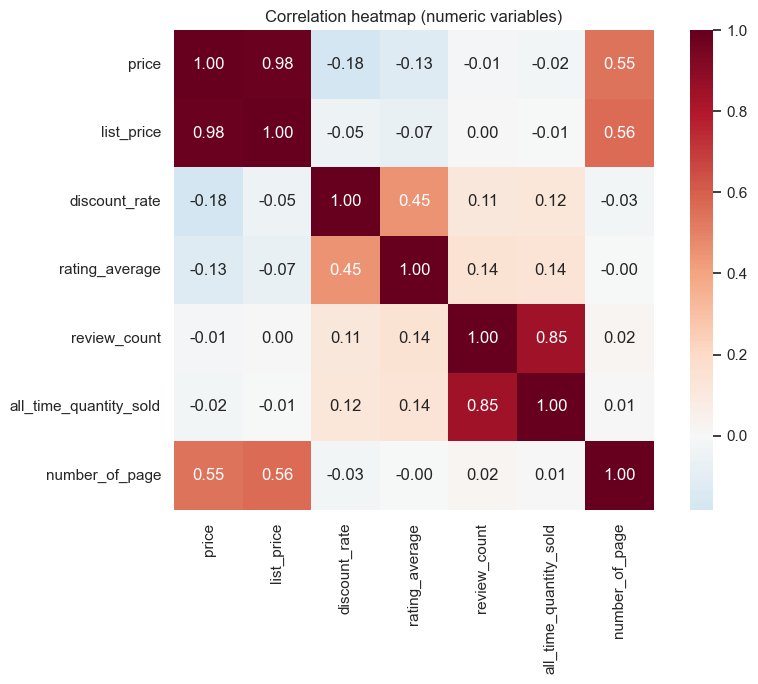

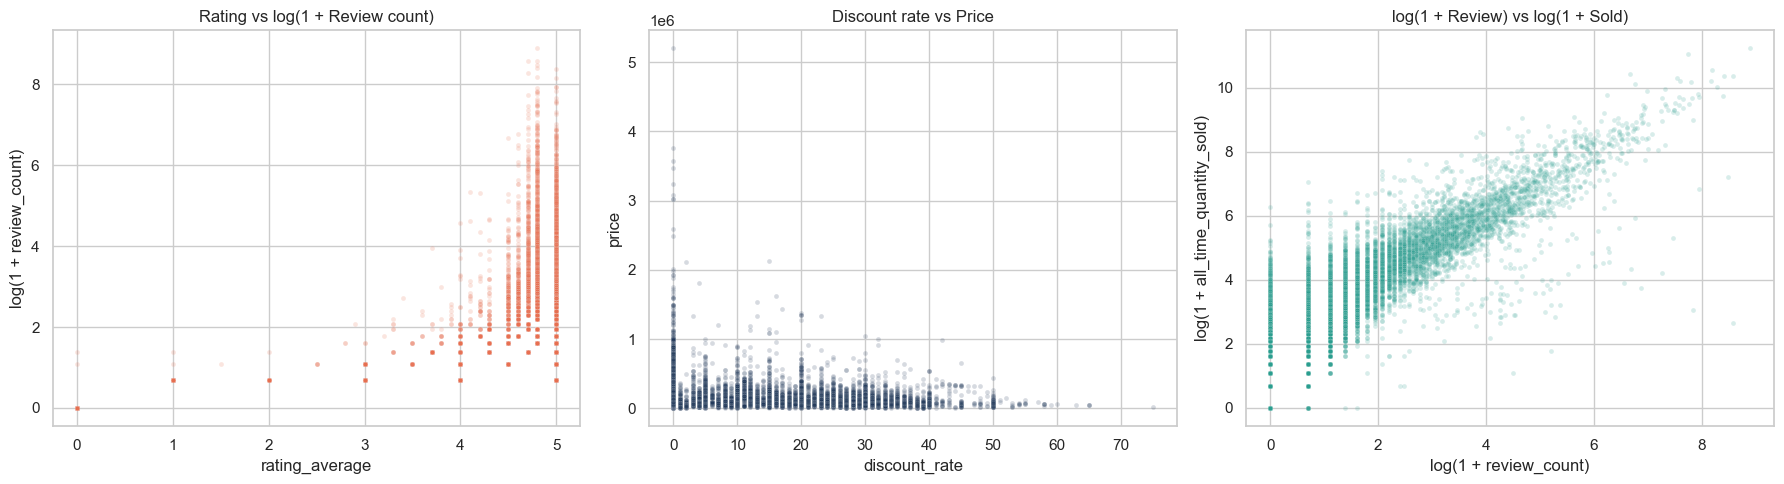

In [19]:
corr_candidates = [
    "price",
    "list_price",
    "discount_rate",
    "rating_average",
    "review_count",
    "all_time_quantity_sold",
    "number_of_page",
]

corr_cols = [c for c in corr_candidates if c in eda_df.columns]
if len(corr_cols) >= 2:
    corr = eda_df[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
    plt.title("Correlation heatmap (numeric variables)")
    plt.tight_layout()
    plt.show()

# Use sampled data for better plotting performance.
sample_df = eda_df.sample(n=min(20000, len(eda_df)), random_state=42).copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Crowd-effect view: rating vs review_count.
if {"rating_average", "review_count"}.issubset(sample_df.columns):
    sample_df["review_count_log1p"] = np.log1p(sample_df["review_count"])
    sns.scatterplot(
        data=sample_df,
        x="rating_average",
        y="review_count_log1p",
        alpha=0.18,
        s=12,
        ax=axes[0],
        color="#e76f51",
    )
    axes[0].set_title("Rating vs log(1 + Review count)")
    axes[0].set_ylabel("log(1 + review_count)")
else:
    axes[0].set_axis_off()

# Pricing structure view: discount vs price.
if {"discount_rate", "price"}.issubset(sample_df.columns):
    sns.scatterplot(
        data=sample_df,
        x="discount_rate",
        y="price",
        alpha=0.18,
        s=12,
        ax=axes[1],
        color="#1d3557",
    )
    axes[1].set_title("Discount rate vs Price")
else:
    axes[1].set_axis_off()

# Sales response view: review_count vs all_time_quantity_sold.
if {"review_count", "all_time_quantity_sold"}.issubset(sample_df.columns):
    sample_df["sold_log1p"] = np.log1p(sample_df["all_time_quantity_sold"])
    sample_df["review_log1p"] = np.log1p(sample_df["review_count"])
    sns.scatterplot(
        data=sample_df,
        x="review_log1p",
        y="sold_log1p",
        alpha=0.18,
        s=12,
        ax=axes[2],
        color="#2a9d8f",
    )
    axes[2].set_title("log(1 + Review) vs log(1 + Sold)")
    axes[2].set_xlabel("log(1 + review_count)")
    axes[2].set_ylabel("log(1 + all_time_quantity_sold)")
else:
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

In [20]:
# Seller and freeship impact analysis.
if {"current_seller_name", "all_time_quantity_sold"}.issubset(eda_df.columns):
    seller_stats = (
        eda_df.groupby("current_seller_name", dropna=False)
        .agg(
            book_count=("id", "count") if "id" in eda_df.columns else (eda_df.columns[0], "count"),
            median_sold=("all_time_quantity_sold", "median"),
            mean_sold=("all_time_quantity_sold", "mean"),
            median_review=("review_count", "median") if "review_count" in eda_df.columns else ("all_time_quantity_sold", "median"),
        )
        .sort_values("book_count", ascending=False)
        .head(15)
    )
    display(seller_stats.round(2))

if {"has_freeship", "all_time_quantity_sold"}.issubset(eda_df.columns):
    freeship_effect = (
        eda_df.groupby("has_freeship", dropna=False)
        .agg(
            book_count=("id", "count") if "id" in eda_df.columns else (eda_df.columns[0], "count"),
            median_sold=("all_time_quantity_sold", "median"),
            mean_sold=("all_time_quantity_sold", "mean"),
            median_price=("price", "median") if "price" in eda_df.columns else ("all_time_quantity_sold", "median"),
            median_rating=("rating_average", "median") if "rating_average" in eda_df.columns else ("all_time_quantity_sold", "median"),
        )
        .round(2)
    )
    print("Freeship effect summary:")
    display(freeship_effect)

,book_count,median_sold,mean_sold,median_review
current_seller_name,,,,
tiki trading,9886,71.50,471.10,5.00
nhà sách fahasa,3428,15.00,59.98,2.00
bamboo books,2385,0.00,1.25,0.00
nhà sách netabooks,1679,0.00,3.14,0.00
nhà sách vĩnh thụy,1665,0.00,0.76,0.00
bookworm hà nội,1131,0.00,0.12,0.00
hệ thống nhà sách abc,989,0.00,0.31,0.00
bảo châu books,963,2.00,7.11,0.00
info book,931,0.00,0.43,0.00


Freeship effect summary:


,book_count,median_sold,mean_sold,median_price,median_rating
has_freeship,,,,,
False,9403,74.00,489.65,"90,720.00",4.80
True,27360,1.00,36.34,"135,000.00",0.00


## 13) Phân tích theo thời gian và ngưỡng review

Bổ sung để phân tích sâu hơn:
- Xu hướng số lượng sách theo năm xuất bản.
- So sánh tín hiệu bán hàng theo các ngưỡng `review_count` (>5, >10, ...).
- Hỗ trợ quyết định lọc outlier cho các biểu đồ crowd effect.

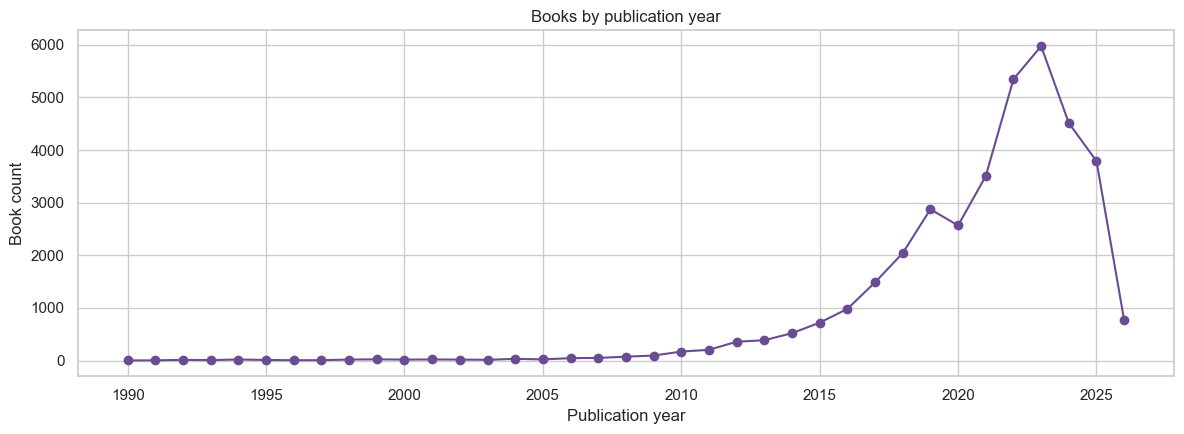

,review_threshold,rows,median_rating,median_review_count,median_sold
0,> 0,15610,5.00,5.00,54.00
1,> 5,7351,5.00,19.00,177.00
2,> 10,5220,4.80,31.00,273.00
3,> 20,3462,4.80,55.00,438.50
4,> 50,1852,4.80,115.00,837.50


In [21]:
# Publication year trend analysis.
if "publication_year" in eda_df.columns:
    year_series = pd.to_numeric(eda_df["publication_year"], errors="coerce")
    year_series = year_series[(year_series >= 1990) & (year_series <= pd.Timestamp.today().year)]

    if not year_series.empty:
        yearly_counts = year_series.value_counts().sort_index()
        plt.figure(figsize=(12, 4.5))
        yearly_counts.plot(kind="line", marker="o", color="#6a4c93")
        plt.title("Books by publication year")
        plt.xlabel("Publication year")
        plt.ylabel("Book count")
        plt.tight_layout()
        plt.show()

# Review threshold sensitivity for crowd-effect analysis.
if {"review_count", "all_time_quantity_sold", "rating_average"}.issubset(eda_df.columns):
    threshold_rows = []
    for threshold in [0, 5, 10, 20, 50]:
        subset = eda_df[eda_df["review_count"] > threshold]
        if len(subset) == 0:
            continue
        threshold_rows.append(
            {
                "review_threshold": f"> {threshold}",
                "rows": int(len(subset)),
                "median_rating": round(float(subset["rating_average"].median()), 3),
                "median_review_count": round(float(subset["review_count"].median()), 3),
                "median_sold": round(float(subset["all_time_quantity_sold"].median()), 3),
            }
        )

    threshold_df = pd.DataFrame(threshold_rows)
    display(threshold_df)

## 15) Kiểm tra giá trị cực đoan và góc nhìn phân bố robust

Một số biến có đuôi rất dài (long-tail) hoặc có giá trị nhập liệu bất thường, khiến biểu đồ gốc khó quan sát phần dữ liệu chính.

Phần này:
- Liệt kê các bản ghi cực đoan để kiểm tra dữ liệu.
- Vẽ lại phân bố theo ngưỡng p99 để quan sát rõ hơn phần lớn dữ liệu.

Extreme-case rows: 23


,id,name,price,list_price,discount_rate,number_of_page
969,12658438,Tủ sách tinh hoa chứng khoán – Đầu tư hiệu quả...,"2,653,000.00","2,653,000.00",0.00,"3,072.00"
1470,57813168,Bộ sách Phân tích kỹ thuật toàn diện kiếm tiền...,"2,595,000.00","2,595,000.00",0.00,"2,774.00"
2600,194103345,Sách Đại Việt sử ký toàn thư (Boxset 2 Quyển),"1,963,000.00","2,500,000.00",21.00,"1,768.00"
8018,193932343,"Đại Việt sử ký toàn thư (trọn bộ 2 quyển, có hộp)","2,125,000.00","2,500,000.00",15.00,"1,768.00"
8837,230062341,Bộ sách Nhập Môn Kungfu Chứng Khoán 2.0 (Gồm 5...,"2,067,000.00","2,067,000.00",0.00,"2,463.00"
9283,477883,Sách Hát Cùng Những Vì Sao,"13,000.00","78,000.00",83.00,111.00
19769,49506137,Dạy Con Làm Giàu - Tập 3: Hướng Dẫn Đầu Tư (Tá...,0.00,"150,000.00",100.00,530.00
21338,279145181,Sách học tiếng Pháp LE PETIT ROBERT DE LA LANG...,"3,020,000.00","3,020,000.00",0.00,"2,880.00"
21675,230056118,Bộ sách Bí Kíp Tăng Trưởng Doanh Thu - Một Vốn...,"2,091,000.00","2,091,000.00",0.00,"2,852.00"
22657,230052285,Bộ Sách Đầu Tư Hiệu Quả Trong Thị Trường Forex...,"3,082,000.00","3,082,000.00",0.00,"3,118.00"


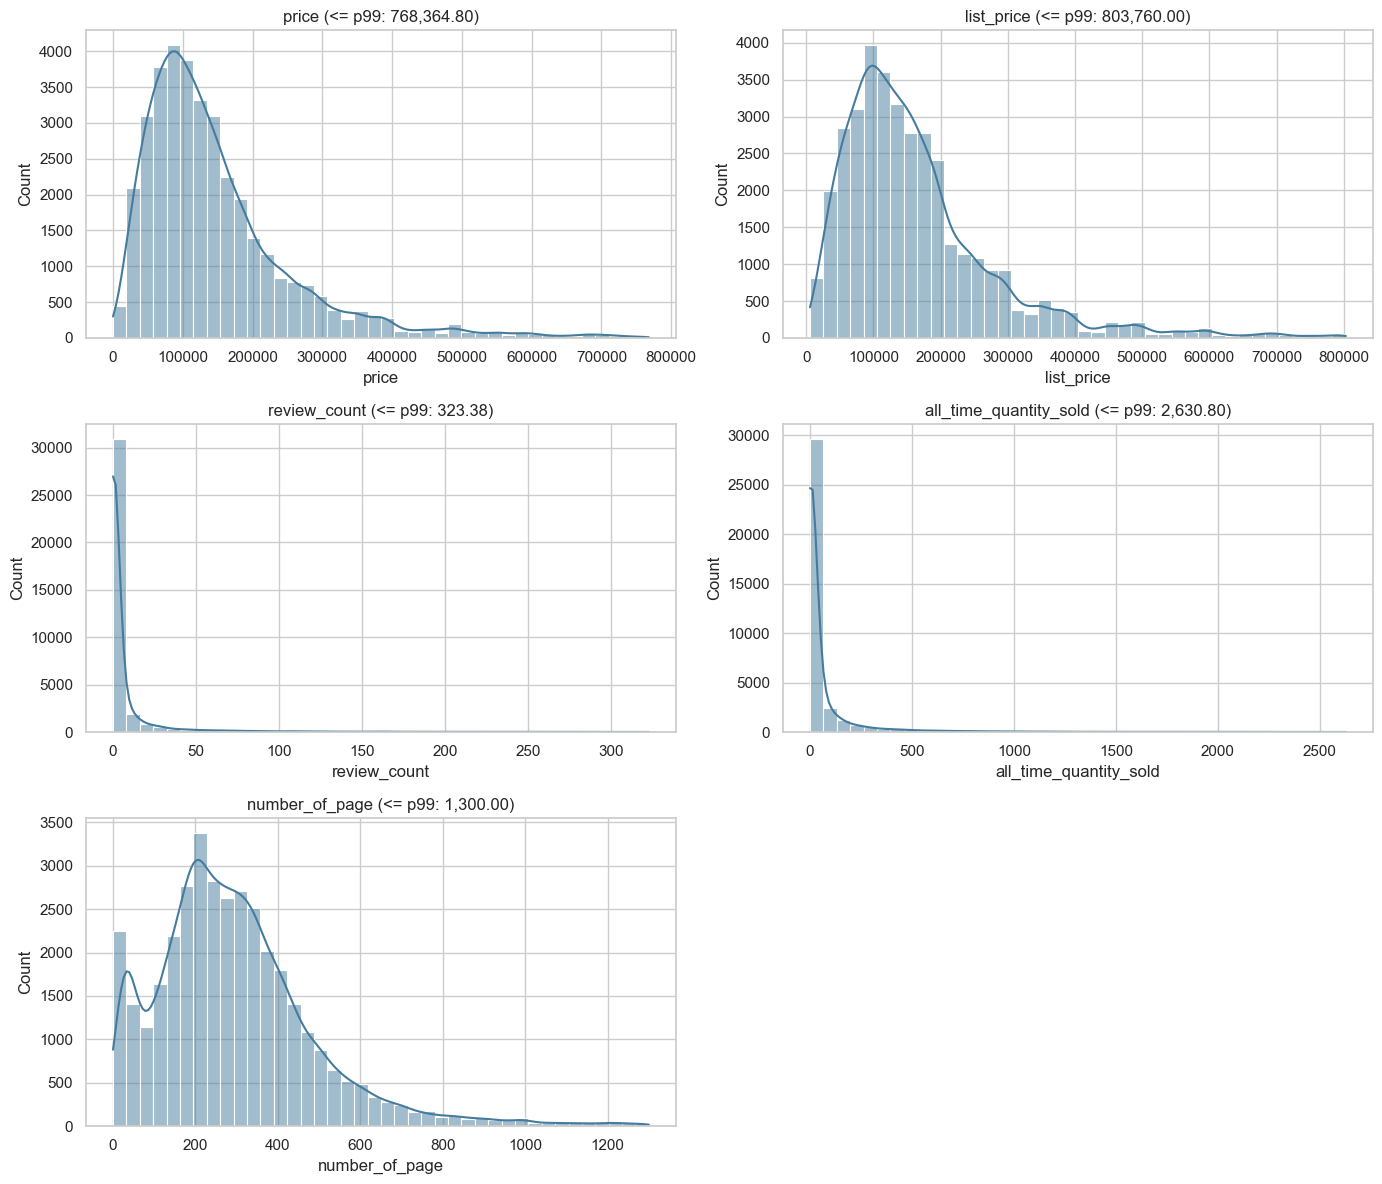

In [22]:
# Detect suspicious extreme values from core numeric columns.
extreme_flags = pd.DataFrame(index=eda_df.index)

if "number_of_page" in eda_df.columns:
    extreme_flags["extreme_pages"] = eda_df["number_of_page"] > 5000
if "price" in eda_df.columns:
    extreme_flags["extreme_price"] = eda_df["price"] > 2_000_000
if "list_price" in eda_df.columns:
    extreme_flags["extreme_list_price"] = eda_df["list_price"] > 2_000_000
if "discount_rate" in eda_df.columns:
    extreme_flags["extreme_discount"] = eda_df["discount_rate"] > 80

if not extreme_flags.empty:
    any_extreme = extreme_flags.any(axis=1)
    extreme_cases = eda_df.loc[any_extreme, [c for c in ["id", "name", "price", "list_price", "discount_rate", "number_of_page"] if c in eda_df.columns]].copy()
    print(f"Extreme-case rows: {len(extreme_cases)}")
    display(extreme_cases.head(20))

# Re-plot key distributions with p99 clipping for readability.
robust_cols = [c for c in ["price", "list_price", "review_count", "all_time_quantity_sold", "number_of_page"] if c in eda_df.columns]
if robust_cols:
    n_cols = 2
    n_rows = int(np.ceil(len(robust_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(robust_cols):
        ax = axes[i]
        s = eda_df[col].dropna()
        if s.empty:
            ax.set_axis_off()
            continue
        upper = s.quantile(0.99)
        clipped = s[s <= upper]
        sns.histplot(clipped, bins=40, kde=True, ax=ax, color="#457b9d")
        ax.set_title(f"{col} (<= p99: {upper:,.2f})")

    for j in range(len(robust_cols), len(axes)):
        axes[j].set_axis_off()

    plt.tight_layout()
    plt.show()